# 07 Analyse – Einfluss des Meeresspiegels auf Überschwemmungen in mediterranen Ländern

**Ziel:** Untersuchen, ob die Höhe des mediterranen Meeresspiegels einen messbaren Einfluss auf das Auftreten von Überschwemmungsereignissen hat.

**Datenbasis:** `flood_linked.parquet` beinhaltet 292 Überschwemmungsereignisse in mediterranen Ländern (1999 bis 2024), angereichert mit täglichen MSL-Anomalien (GIA-korrigiert) aus dem Copernicus Marine Service.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

from myproj.io.import_data import find_project_root
df = pd.read_parquet(find_project_root() / "data" / "processed" / "flood_linked.parquet")
print(f"Datensatz: {df.shape[0]} Ereignisse, {df.shape[1]} Spalten")
print(f"Zeitraum:  {df['start_date'].dt.year.min()}–{df['start_date'].dt.year.max()}")

Datensatz: 292 Ereignisse, 28 Spalten
Zeitraum:  1999–2024


## 1. Deskriptive Übersicht

Welche Muster zeigen sich in der Verteilung der Ereignisse nach Zeit, Saison, Land und Typ?

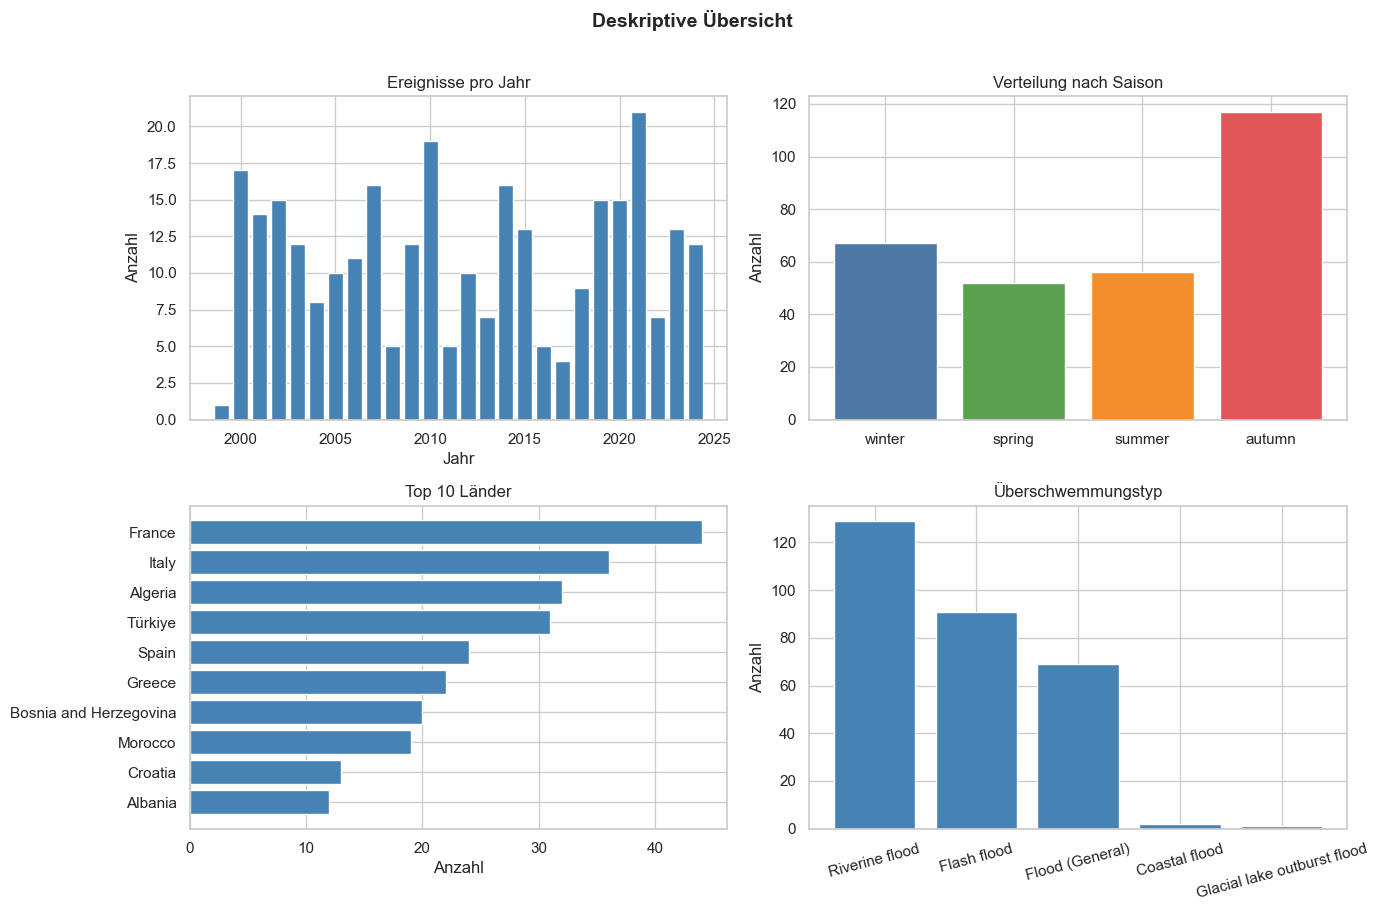

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Deskriptive Übersicht", fontsize=14, fontweight="bold", y=1.01)

yearly_count = df.groupby(df["start_date"].dt.year).size()
axes[0, 0].bar(yearly_count.index, yearly_count.values, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Ereignisse pro Jahr")
axes[0, 0].set_xlabel("Jahr")
axes[0, 0].set_ylabel("Anzahl")

season_order = ["winter", "spring", "summer", "autumn"]
season_counts = df["season"].value_counts().reindex(season_order)
season_colors = ["#4e79a7", "#59a14f", "#f28e2b", "#e15759"]
axes[0, 1].bar(season_counts.index, season_counts.values, color=season_colors, edgecolor="white")
axes[0, 1].set_title("Verteilung nach Saison")
axes[0, 1].set_ylabel("Anzahl")

top_countries = df["Country"].value_counts().head(10)
axes[1, 0].barh(top_countries.index[::-1], top_countries.values[::-1], color="steelblue")
axes[1, 0].set_title("Top 10 Länder")
axes[1, 0].set_xlabel("Anzahl")

subtype_counts = df["Disaster Subtype"].value_counts()
axes[1, 1].bar(subtype_counts.index, subtype_counts.values, color="steelblue", edgecolor="white")
axes[1, 1].set_title("Überschwemmungstyp")
axes[1, 1].set_ylabel("Anzahl")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

**Beobachtungen**
- Frankreich, Italien, Algerien und die Türkei dominieren mit je über 30 Ereignissen.
- Herbst ist mit Abstand die häufigste Saison, was dem Muster mediterraner Herbstniederschläge entspricht.
- Die Ereignisanzahl pro Jahr schwankt stark (min. 1 in 1999, max. 21 in 2021). Ein klarer langfristiger Trend ist nicht erkennbar.

## 2. Verteilung und Trend des Meeresspiegels

Wie verteilt sich der Meeresspiegel bei den Ereignissen, und gibt es einen zeitlichen Trend?

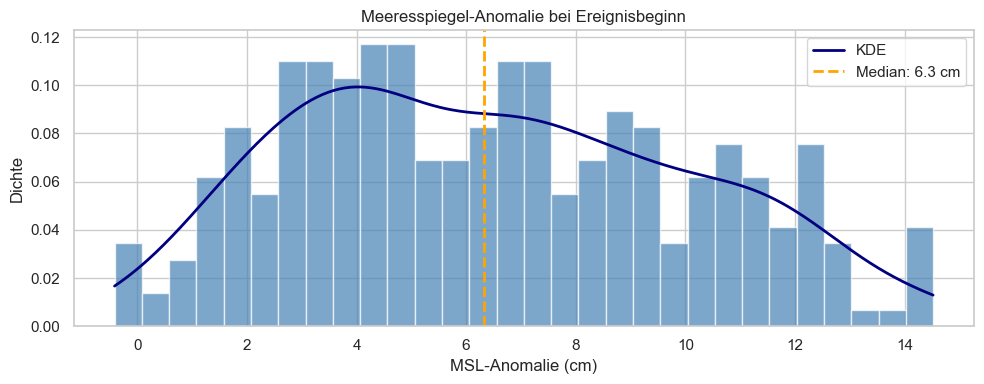

In [16]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(
    df["sea_level_at_start"], bins=30, color="steelblue",
    edgecolor="white", density=True, alpha=0.7
)
kde = gaussian_kde(df["sea_level_at_start"])
x = np.linspace(df["sea_level_at_start"].min(), df["sea_level_at_start"].max(), 300)
ax.plot(x, kde(x), color="navy", lw=2, label="KDE")
median_sl = float(df["sea_level_at_start"].median())
ax.axvline(median_sl, color="orange", lw=2, linestyle="--", label=f"Median: {median_sl:.1f} cm")
ax.set_title("Meeresspiegel-Anomalie bei Ereignisbeginn")
ax.set_xlabel("MSL-Anomalie (cm)")
ax.set_ylabel("Dichte")
ax.legend()
plt.tight_layout()
plt.show()

**Beobachtungen**
- Die Verteilung zeigt den MSL an den Tagen, an denen Flood-Events begannen.
- Die Werte streuen von rund 0 bis 14.5 cm bei einem Median von 6.3 cm

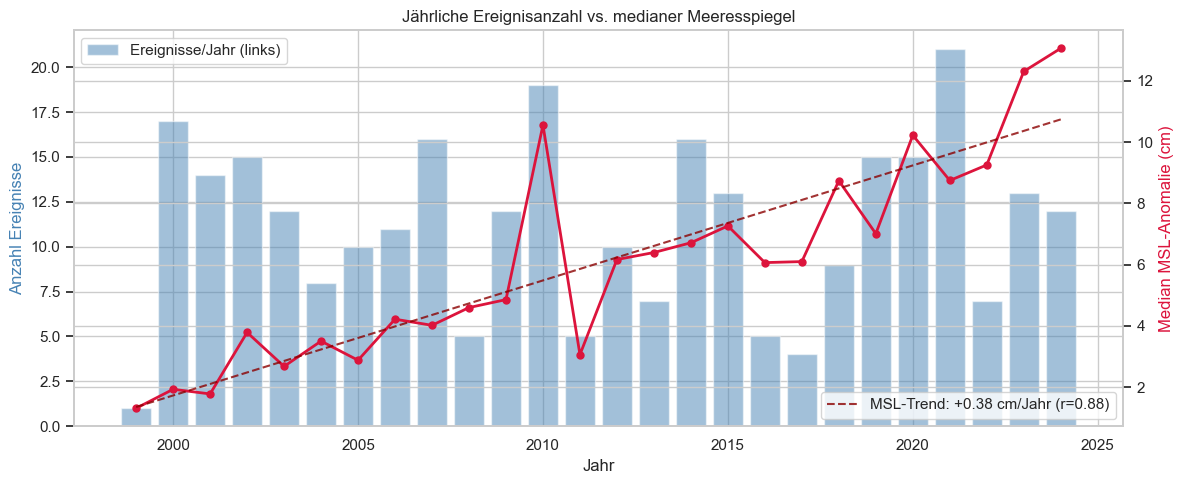

MSL-Trend:       +0.375 cm/Jahr     | r=0.883, p=0.0000
Ereignis-Trend:  +0.055 Ereignisse/Jahr | r=0.085, p=0.6796


In [17]:
yearly = df.groupby(df["start_date"].dt.year).agg(
    count=("DisNo.", "count"),
    median_sl=("sea_level_at_start", "median")
).reset_index()

slope_sl, intercept_sl, r_sl, p_sl, _ = stats.linregress(yearly["start_date"], yearly["median_sl"])
slope_cnt, _, r_cnt, p_cnt, _ = stats.linregress(yearly["start_date"], yearly["count"])

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

bars = ax1.bar(yearly["start_date"], yearly["count"], alpha=0.5, color="steelblue")
ax2.plot(
    yearly["start_date"], yearly["median_sl"],
    color="crimson", marker="o", markersize=5, lw=2
)
ax2.plot(
    yearly["start_date"],
    intercept_sl + slope_sl * yearly["start_date"],
    "--", color="darkred", alpha=0.8,
    label=f"MSL-Trend: +{slope_sl:.2f} cm/Jahr (r={r_sl:.2f})"
)

ax1.set_xlabel("Jahr")
ax1.set_ylabel("Anzahl Ereignisse", color="steelblue")
ax2.set_ylabel("Median MSL-Anomalie (cm)", color="crimson")
ax1.set_title("Jährliche Ereignisanzahl vs. medianer Meeresspiegel")
ax1.legend([bars], ["Ereignisse/Jahr (links)"], loc="upper left")
ax2.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"MSL-Trend:       +{slope_sl:.3f} cm/Jahr     | r={r_sl:.3f}, p={p_sl:.4f}")
print(f"Ereignis-Trend:  +{slope_cnt:.3f} Ereignisse/Jahr | r={r_cnt:.3f}, p={p_cnt:.4f}")

**Beobachtungen**
- Der MSL bei Flood-Events steigt deutlich an, rund +0.38 cm pro Jahr bei einer Korrelation von r = 0.88. Der Anstieg entspricht dem bekannten physikalischen Trend des steigenden Mittelmeerspiegels und ist im Datensatz klar erkennbar. Ein exakter p-Wert wird bewusst nicht betont, weil die jährlichen Medianwerte autokorreliert sind und eine naive Regression die Signifikanz überschätzt.
- Die jährliche Ereignisanzahl zeigt dagegen keinen erkennbaren Trend (r = 0.09).

## 3. Treten Floods bei überdurchschnittlichem Meeresspiegel auf?

Häufen sich Überschwemmungen an Tagen mit erhöhtem Meeresspiegel?

**Problem:** MSL und Ereignishäufigkeit teilen einen starken gemeinsamen Zeittrend (Abschnitt 2). Ein direkter Vergleich der absoluten MSL-Werte wäre dadurch verfälscht.

**Lösung über Trendbereinigung:** Wir betrachten das Residuum `sea_level_at_start − sea_trend_at_start`, also die Abweichung des MSL vom Copernicus-Langzeittrend am Ereignistag. Der gemeinsame Zeittrend ist damit eliminiert (Korrelation zwischen Residuum und Zeit nahe 0).

**Test:** One-sample t-Test der Flood-Residuen gegen 0. Die Pipeline loggt beim Transform-Schritt (`add_sea_level_z_scores`, Feld `detrend_ref`), dass das mittlere Residuum über alle 9'405 Tage bei rund 0 cm liegt. 0 ist damit die korrekte Nullreferenz. Ein Mittelwert über 0 bedeutet, dass Floods bei über dem Trend liegendem MSL auftreten.

**Verbleibende Einschränkung:** `flood_linked.parquet` enthält nur Flood-Tage. Ein direkter Vergleich mit Nicht-Flood-Tagen ist somit nicht möglich (Mehr dazu im Fazit). Der Test gegen die verifizierte Null-Baseline ist die bestmögliche Näherung mit diesem Datensatz.

In [18]:
# Trendbereinigtes Residuum am Ereignistag
resid = (df["sea_level_at_start"] - df["sea_trend_at_start"]).dropna()
t, p = stats.ttest_1samp(resid, 0)
cohens_d = resid.mean() / resid.std(ddof=1)

print(f"Flood-Residuen (MSL − Trend), n = {len(resid)}")
print(f"  mittleres Residuum: {resid.mean():+.3f} cm")
print(f"  Standardabweichung: {resid.std(ddof=1):.3f} cm")
print(f"  t-Test gegen 0:     t = {t:.3f}, p = {p:.4f}")
print(f"  Effektgrösse:       Cohen's d = {cohens_d:.3f}")

# Persistenz an den Vortagen (Trend über 5 Tage praktisch konstant)
lag_cols = ["sea_level_lag_1d", "sea_level_lag_2d", "sea_level_lag_3d",
            "sea_level_lag_4d", "sea_level_lag_5d"]
lag_labels = ["Tag −1", "Tag −2", "Tag −3", "Tag −4", "Tag −5"]
lag_means, lag_ps = [], []
print("\nPersistenz an den Vortagen:")
for col, label in zip(lag_cols, lag_labels):
    r = (df[col] - df["sea_trend_at_start"]).dropna()
    t_, p_ = stats.ttest_1samp(r, 0)
    lag_means.append(float(r.mean()))
    lag_ps.append(float(p_))
    print(f"  {label}: mittleres Residuum = {r.mean():+.3f} cm | t = {t_:.3f} | p = {p_:.4f}")

Flood-Residuen (MSL − Trend), n = 292
  mittleres Residuum: +0.364 cm
  Standardabweichung: 2.185 cm
  t-Test gegen 0:     t = 2.847, p = 0.0047
  Effektgrösse:       Cohen's d = 0.167

Persistenz an den Vortagen:
  Tag −1: mittleres Residuum = +0.365 cm | t = 2.860 | p = 0.0045
  Tag −2: mittleres Residuum = +0.366 cm | t = 2.873 | p = 0.0044
  Tag −3: mittleres Residuum = +0.367 cm | t = 2.884 | p = 0.0042
  Tag −4: mittleres Residuum = +0.368 cm | t = 2.895 | p = 0.0041
  Tag −5: mittleres Residuum = +0.368 cm | t = 2.905 | p = 0.0040


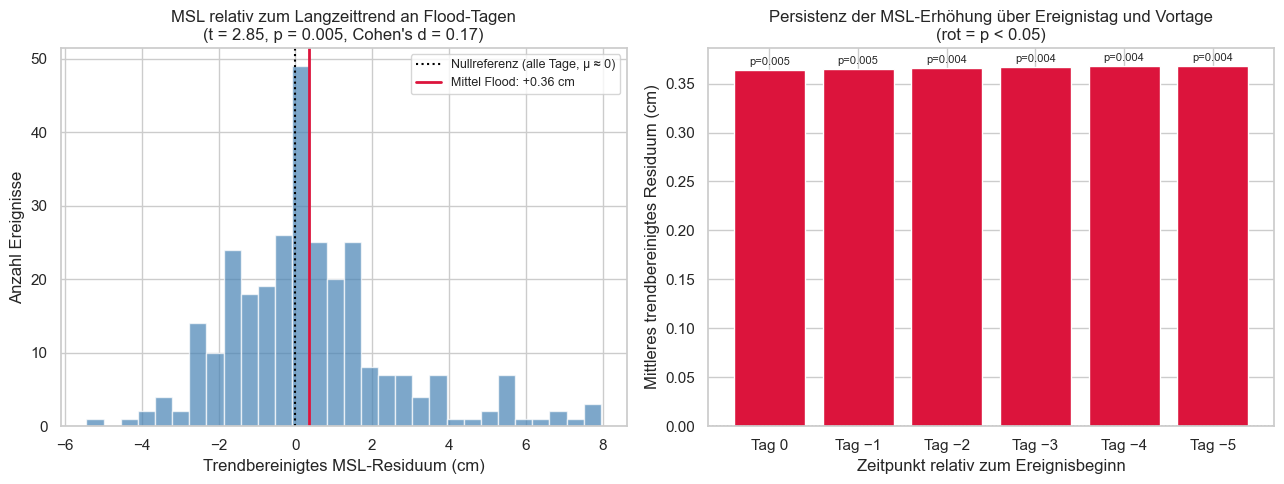

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Verteilung der Residuen am Ereignistag
ax = axes[0]
ax.hist(resid, bins=30, color="steelblue", alpha=0.7, edgecolor="white")
ax.axvline(0, color="black", lw=1.5, linestyle=":", label="Nullreferenz (alle Tage, μ ≈ 0)")
ax.axvline(resid.mean(), color="crimson", lw=2,
           label=f"Mittel Flood: {resid.mean():+.2f} cm")
ax.set_xlabel("Trendbereinigtes MSL-Residuum (cm)")
ax.set_ylabel("Anzahl Ereignisse")
ax.set_title(f"MSL relativ zum Langzeittrend an Flood-Tagen\n"
             f"(t = {t:.2f}, p = {p:.3f}, Cohen's d = {cohens_d:.2f})")
ax.legend(fontsize=9)

# Persistenz Tag 0 bis Tag -5
ax2 = axes[1]
labels = ["Tag 0"] + lag_labels
means = [float(resid.mean())] + lag_means
ps = [p] + lag_ps
colors = ["crimson" if pv < 0.05 else "steelblue" for pv in ps]
bars = ax2.bar(labels, means, color=colors, edgecolor="white")
ax2.axhline(0, color="black", lw=1, linestyle=":")
ax2.set_ylabel("Mittleres trendbereinigtes Residuum (cm)")
ax2.set_xlabel("Zeitpunkt relativ zum Ereignisbeginn")
ax2.set_title("Persistenz der MSL-Erhöhung über Ereignistag und Vortage\n(rot = p < 0.05)")
for bar, pv in zip(bars, ps):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"p={pv:.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

**Beobachtungen**
- Nach Trendbereinigung liegt der Meeresspiegel an Flood-Tagen im Mittel **+0.36 cm über dem Langzeittrend** (t = 2.85, p = 0.005). Weil der gemeinsame Zeittrend entfernt ist und die Nullreferenz über alle Tage verifiziert bei rund 0 liegt, ist dies ein **echter, nicht durch den Trend verfälschter** positiver Zusammenhang.
- Die **Effektgrösse ist klein** (Cohen's d rund 0.17). Floods treten statistisch robust, aber betragsmässig nur leicht bei über dem Trend liegendem MSL auf.
- Der Persistenz-Check zeigt an allen 5 Vortagen praktisch denselben Wert (+0.36 cm). Die Erhöhung ist also ein **anhaltender Zustand** und kein Tag-0-Ausschlag. Das liegt an der hohen Autokorrelation des Meeresspiegels und liefert daher **keinen** zusätzlichen Vorhersagewert.

## 4. Fazit

### Meeresspiegel-Trend
- Der mediterrane Meeresspiegel steigt im Datensatz deutlich an, rund +0.38 cm pro Jahr bei einer Korrelation von r = 0.88.
- Die jährliche Ereignisanzahl zeigt keinen erkennbaren Trend (r = 0.09).

### Meeresspiegel und Flood-Auftreten (Kernfrage)
- Nach Trendbereinigung liegt der MSL an Flood-Tagen im Mittel +0.36 cm über dem Langzeittrend (t = 2.85, p = 0.005, Cohen's d rund 0.17). Der gemeinsame Zeittrend ist dabei eliminiert und die Nullreferenz verifiziert. Der Zusammenhang ist also statistisch robust, aber betragsmässig klein.
- Die Erhöhung ist über den Ereignistag und die 5 Vortage praktisch konstant, ein anhaltender Zustand durch die hohe Autokorrelation des Meeresspiegels.
- Diese Konstanz ist ein indirektes Indiz dafür, dass der Meeresspiegel die Floods nicht auslöst. Weil sich der MSL über Tage kaum verändert, kann er nicht erklären, warum ein Flood ausgerechnet an einem bestimmten Tag auftritt. Diese Rolle übernehmen schnell veränderliche Auslöser wie der Niederschlag. Der Meeresspiegel kann somit höchstens eine langsam wirkende Hintergrundbedingung sein, was zur kleinen Erhöhung von +0.36 cm passt.

### Strukturelle Limitation (Datensatzformat)
Der Zeittrend-Confounder ist durch die Trendbereinigung behandelt. Was bleibt, ist die Beschränkung des Datensatzes. `flood_linked.parquet` enthält nur Flood-Tage. Wir haben bemerkt, dass es für eine kausale Aussage darüber, ob erhöhter MSL mehr Floods verursacht, einen Datensatz mit einer Zeile pro Tag inklusive Nicht-Flood-Tagen und der Zielvariable `flood_occurred` bräuchte. Damit wären logistische Regression und ein echter Vergleich von Flood- und Nicht-Flood-Tagen möglich. Mit dem aktuellen Datensatz ist die Frage näherungsweise beantwortbar (ein positiver, kleiner, trendbereinigter Zusammenhang), aber nicht kausal.

### Inhaltliche Limitation (Flood-Typ und Geografie)
- Ein direkter Einfluss des Meeresspiegels ist vor allem bei Coastal Floods zu erwarten, davon gibt es aber nur 2 von 292 Ereignissen. Die Mehrheit sind Regen-getriebene Riverine Floods (129) und Flash Floods (91), dazu ein Glacial Lake Outburst Flood (1) ohne jeden Meeresspiegel-Bezug. Für diese Typen ist der Mittelmeer-Meeresspiegel höchstens ein indirekter Proxy über gemeinsame Wetterlagen, also Stürme, die zugleich Regen bringen und den Meeresspiegel kurzfristig anheben.
- Ob ein Ereignis überhaupt zum Mittelmeer-Einzugsgebiet gehört, lässt sich nicht prüfen. Riverine Floods können an Flüssen liegen, die nicht ins Mittelmeer entwässern. Diese Zuordnung wäre nur über Koordinaten möglich, die bei 78 Prozent der Ereignisse fehlen.
- Aussagekräftiger als der Meeresspiegel wären Niederschlagsdaten gewesen, weil Regen der direkte Auslöser der dominierenden Riverine- und Flash-Floods ist. Der verwendete MSL ist zudem ein langsam variierender, flächengemittelter Klima-Indikator und erfasst keine akuten Sturmfluten.
